In [1]:
from langgraph.graph import StateGraph, START, END

from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node

from spm_agent.states.image_analysis_state import ImageAnalysisState

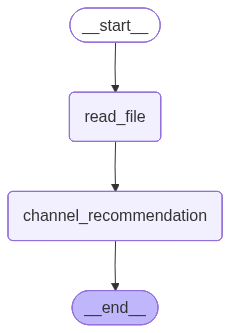

In [2]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)
builder.add_node("channel_recommendation", channel_recommendation_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", "channel_recommendation")
builder.add_edge("channel_recommendation", END)

im_graph = builder.compile()
im_graph

In [3]:
from spm_agent.config import SCIFIREADERS_MCP_COMMAND
print(SCIFIREADERS_MCP_COMMAND)

c:\Users\Asylum User\Documents\GitHub\SPM_agent_simple\.venv\Scripts\scifireaders_mcp.EXE


In [4]:
result = await im_graph.ainvoke(
    {
        "file_path": r"C:\Users\Asylum User\Documents\Asylum Research Data\260602\plzt0_0000.ibw",
    }
)

payload type: <class 'dict'>
payload keys: dict_keys(['result'])
payload preview: {'result': {'file_path': 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260602\\plzt0_0000.ibw', 'return_mode': 'data', 'available_readers': [{'name': 'DMReader', 'module': 'SciFiReaders.readers.microscopy.em.tem.dm_reader', 'doc': 'Reader of Digital Micrograph image and spectroscopy data'}, {'name': 'DM3Reader', 'module': 'SciFiReaders.readers.microscopy.em.tem.dm_reader', 'doc': 'DM3 file reader class.'}, {'name': 'NionReader', 'module': 'SciFiReaders.readers.microscopy.em.tem.nion_reader', 'doc': 'Reader for Nion ndata and h5 files'}, {'name': 'EMDReader', 'module': 'SciFiReaders.readers.microscopy.em.tem.emd_reader', 'doc': 'Creates an instance of EMDReader which can read one or more HDF5'}, {'name': 'MRCReader', 'module': 'SciFiReaders.readers.microscopy.em.tem.mrc_reader', 'doc': ''}, {'name': 'EDAXReader', 'module': 'SciFiReaders.readers.microscopy.em.sem.edax_reader', 'doc': 'Creates an

In [7]:
from pprint import pprint

In [13]:
pprint(result['channel_recommendations']['task_recommendation'][4])

{'confidence': 0.56,
 'feasible': True,
 'primary_channel': 'Channel_000',
 'reasoning': 'HeightRetrace is the best available channel for possible '
              'contamination because particulate/raised debris would most '
              'directly appear in topography, and several localized bright '
              'features are visible. Amplitude channels may provide supporting '
              'evidence where contaminants perturb tip-sample coupling, but '
              'they are not specific. No dedicated '
              'adhesion/current/deflection-type channel is available, so '
              'contamination identification is only moderately supported.',
 'secondary_channels': ['Channel_001', 'Channel_002'],
 'task': 'surface_contamination_detection',
 'warnings': ['Surface contamination is uncertain from the available channels '
              'because topography is dominated by linear features and rough '
              'texture.',
              'Amplitude contrast changes are not sp